## Creating Misclassifications in Datasets ##

**Authors: Arnout van Delden, Naomi Schalken, Sander Scholtus, Dewi Peerlings and Liu Nuo Su**

<img src="misc/beans_label.png" alt="Misclassified Beans" width="750"/>

<!-- Photo by [Graddes](https://unsplash.com/@graddes) on [Unsplash](https://unsplash.com/photos/a-glass-jar-filled-with-coffee-beans-sitting-on-top-of-a-table-NW8NnW5SU60) -->


Classifications are labels are used everywhere in our daily lives. While underlying characteristics and information are considered in labeling an object, mislabeling can occur if characteristics are too similar across categories. In this context, the observed labels can differ from the underlying true labels, defined as a misclassification. We introduce a script to generate misclassifications in a dataset: we demonstrate how to make an observed label column based on the given labels, using Kaggle's [Dry Bean Dataset](https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset) as example.

### Importing packages and Files ###

In [2]:
import pandas as pd
import numpy as np
import pickle
import os 
import seaborn as sns
import matplotlib.pyplot as plt

To generate the misclassified labels, we start with an existing classification table used in [Koklu, Ozkan (2020)](https://www.sciencedirect.com/science/article/abs/pii/S0168169919311573). The classification table used is the aggregated classifications of the four machine learning models; MLP, SVM, kNN, and DT with a 10-fold cross validation.

In [3]:
# Loading in the dry beans dataset
# Cm matrix gemaakt door een aantal modellen die bonen voorspellen -> cite hun artikel, pak gemiddelde van de 4 machine learning modellen
# vMP onderzoek projecten, textmingnig ,em_mixturemodel, droge bonen, derivationtransitionmatrices_drybeans.dockx
# PDF -> artikel koklu ozlan 2020 tabellen 8,9,10,11
# murat koklu, ozlan multiclass classification of dry beans using computer vision and machine learning techniques
# aanpak droge bonen arnout 230220 
cm = pd.read_csv('dry_beans/cm_drybeans.csv', sep=';') 
cm.columns = [c.upper() for c in cm.columns]
cm['ACTUAL'] = cm['ACTUAL'].str.upper()
print(cm.head())

     ACTUAL  BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
0  BARBUNYA      1184       4    87         2      3     10    32
1    BOMBAY         1     518     3         0      0      0     0
2      CALI        44       5  1530         0     34      3    14
3  DERMASON         1       0     0      3293      2     52   198
4     HOROZ         5       0    29        16   1829      0    49


In [4]:
# create the average cm, use this as the main transition matrix (no background variables used)
cm_agg = cm.groupby('ACTUAL').agg(lambda x:  np.mean(x))
cm_sum = cm_agg.sum(axis=1)
trans = cm_agg.apply(lambda x: x / np.sum(x.values), axis=1) 
trans.sum(axis=1)
trans.to_csv('dry_beans/transition_matrix_drybeans.csv', sep=';')

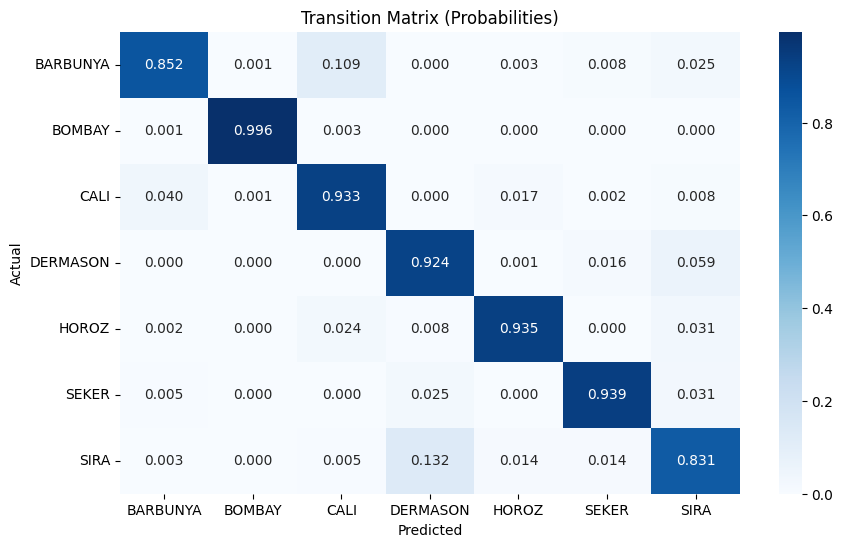

In [5]:
plt.figure(figsize=(10, 6))
classes = trans.columns
sns.heatmap(trans, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Transition Matrix (Probabilities)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

We see that many of the probabilities are near 1 on the diagonal. Several beans are linked closer to some beans than others. For example, Barbunya is often classified as Cali, and Sira as Dermason. Next, we introduce the background variables:

In [6]:
# data from Kaggle with background characteristics of the beans
data = pd.read_csv('dry_beans/Dry_Bean.csv') 
bg_values = [1, 2, 3, 4]
bg_err ={1: 0.3, 2: 0.15, 3: 0.1, 4: 0.01} #Dit hebben we verzonnen en dat zijn de fouten waar je op uit wil komen. 
class_names = ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
np.random.seed(230329)
data['background'] = np.random.choice(a=bg_values, size=len(data), p=[0.4, 0.3, 0.2, 0.1])
print(data.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  \
0     0.913358      0.007332 

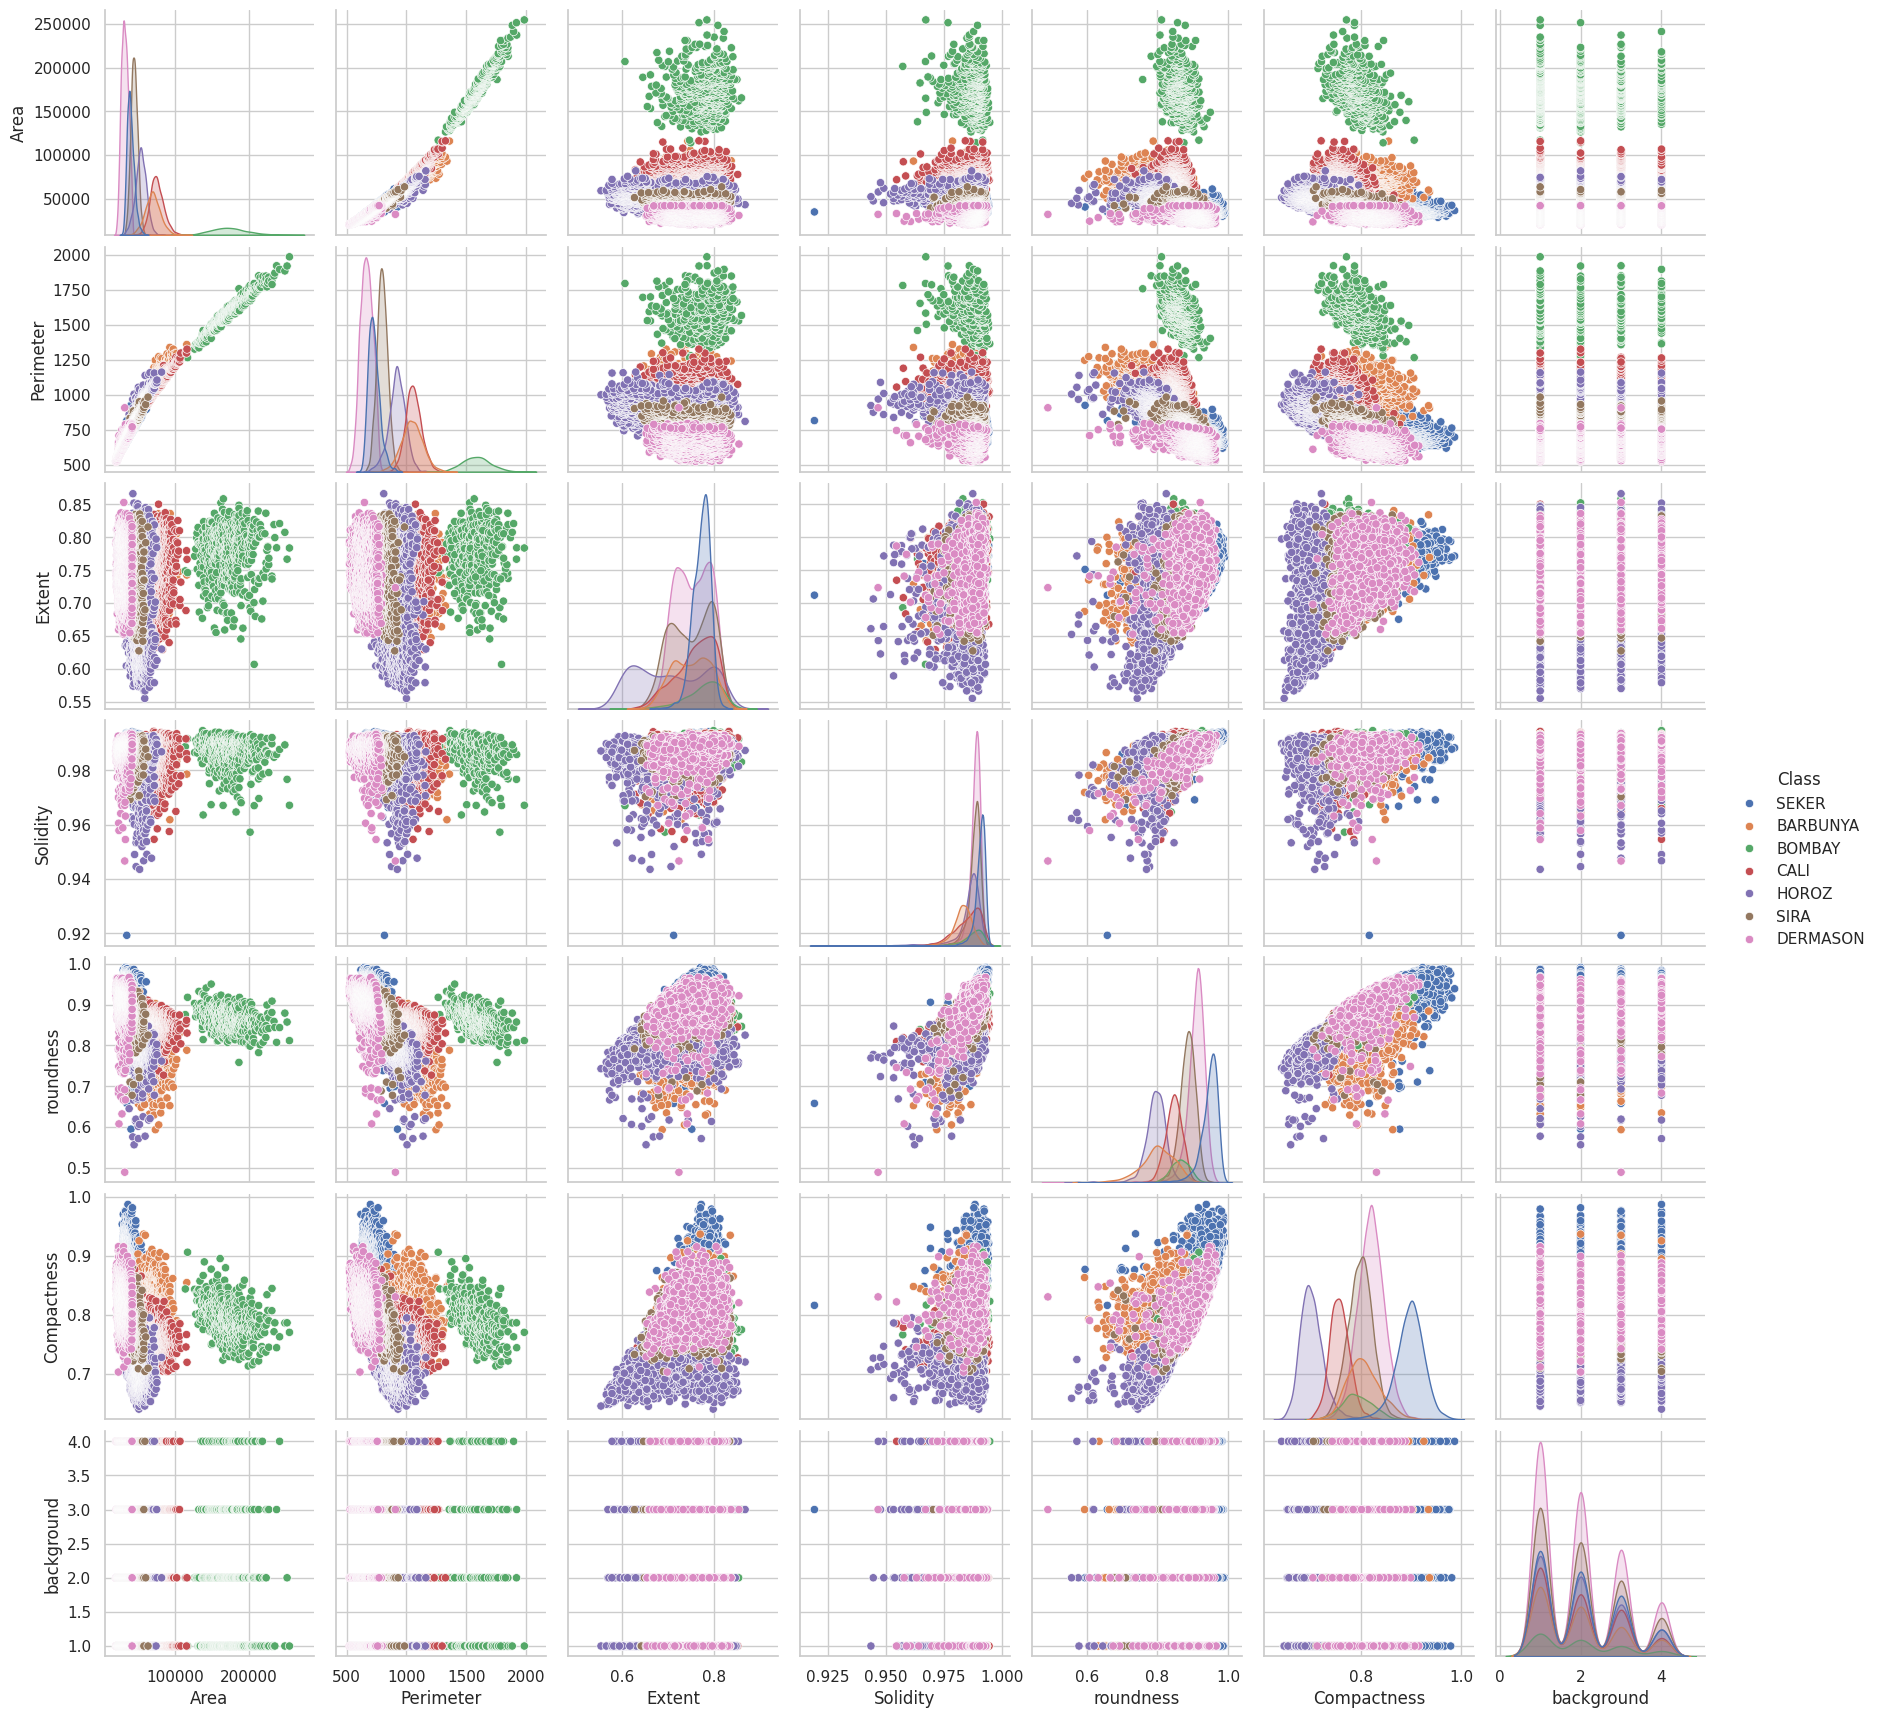

In [7]:
#Visualisation for 6 variable Scatterplot including Class labels
data6 = data[["Area","Perimeter","AspectRation","Eccentricity","roundness","Compactness", "background","Class",]]
data6 = data[["Area","Perimeter","Extent","Solidity","roundness","Compactness","background","Class"]]
data6.head()
sns.set_theme(style="whitegrid")
sns.pairplot(data6, hue="Class")

### Part 1: Introducing Golden, Noisy and Background population sets ###
We introduce a golden set, defined as observations that have a truelabel equal to the observed label. We sample 100 rows from each class in our data.

In [8]:
# create gold set
gold100 = data.groupby('Class').sample(n=100, random_state=230329).reset_index()
data['gold100'] = 0
data.loc[data.index.isin(gold100['index']),'gold100'] = 1
print(data.groupby(["gold100","Class"]).size())

gold100  Class   
0        BARBUNYA    1222
         BOMBAY       422
         CALI        1530
         DERMASON    3446
         HOROZ       1828
         SEKER       1927
         SIRA        2536
1        BARBUNYA     100
         BOMBAY       100
         CALI         100
         DERMASON     100
         HOROZ        100
         SEKER        100
         SIRA         100
dtype: int64


We copy the remaining non-golden set rows, and define them as our noisy set. From the noisy set, we construct the populations of each background group (1, 2, 3 and 4). We work with these sets of data to construct our errors.

In [9]:
# create noisy set
noisy = data[data['gold100']==0].copy()
pop_bg_class = noisy.groupby(['background', 'Class']).size().reset_index()
pop_bg_class = pop_bg_class.pivot(index='background', columns='Class', values=0).reset_index()
pop_bg_class.rename(columns={'Class': 'background'}, inplace=True)
pop_bg_class.rename_axis('', axis='columns', inplace=True)
print(pop_bg_class)

   background  BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
0           1       508     175   642      1370    709    722  1003
1           2       364     127   432      1051    560    588   770
2           3       226      80   332       684    369    426   505
3           4       124      40   124       341    190    191   258


### Part 2: Constructing error probability matrices ###

We allow for dependencies in our errortypes through the construction of probability matrices in our misclassifications. We consider the errors per class and per background value, and reshape them based on our populations. 

In [10]:
# Obtain error percentages from diagonal
err_perc_beans = 1 - trans[class_names].values.diagonal()
tot_pop = noisy.shape[0]

# Since errors are limited, we introduce three times the amount per class
err_perc_beans3 = err_perc_beans*3
print(err_perc_beans3)

# Total amount per background variable and per bean class
sum_bg = pop_bg_class.loc[:, pop_bg_class.columns != "background"].sum(axis=1)
sum_beans = pop_bg_class.loc[:, pop_bg_class.columns != "background"].sum(axis=0)

[0.44251135 0.01293103 0.20245399 0.22673435 0.19450207 0.18241243
 0.50572136]


Now that we have the error percentages per bean, we construct the error percentage per background class. The error percentages per background variables are chosen arbitrarily, and are transformed into the non-rounded amount of observations, based on the amount of rows.

In [11]:
# Error percentage per background value
err_perc_bg = np.array([0.3, 0.15, 0.1, 0.01])

# Calculate the number of errors for every bean and bg
n_err_beans = err_perc_beans3*sum_beans
n_err_bg = err_perc_bg*sum_bg
print(pd.DataFrame(n_err_beans).T)
print(pd.DataFrame(n_err_bg).T)

     BARBUNYA    BOMBAY        CALI    DERMASON       HOROZ       SEKER  \
0  540.748865  5.456897  309.754601  781.326565  355.549793  351.508757   

          SIRA  
0  1282.509378  
        0      1      2      3
0  1538.7  583.8  262.2  12.68


In [12]:
# Sum total number of errors beans and bg, tallied over all beans and all backgrounds.
tot_err_beans = n_err_beans.sum(axis=0)
tot_err_bg = n_err_bg.sum(axis=0)
print("Total amount of errors in beans: ", tot_err_beans, "\nTotal amount of errors in bg:", tot_err_bg)

Total amount of errors in beans:  3626.8548559104092 
Total amount of errors in bg: 2397.3799999999997


In [13]:
# Rescale n_err_bg to add up to tot_err_beans: they must be the same
n_err_bg_rescaled = n_err_bg*(tot_err_beans/tot_err_bg)

# Relative number of errors, with the background percentage rescaled
rel_beans = n_err_beans/tot_err_beans
rel_bg = n_err_bg_rescaled/tot_err_beans
print(pd.DataFrame(rel_beans).T)
print(pd.DataFrame(rel_bg).T)

   BARBUNYA    BOMBAY      CALI  DERMASON     HOROZ     SEKER      SIRA
0  0.149096  0.001505  0.085406  0.215428  0.098033  0.096918  0.353615
          0         1         2         3
0  0.641826  0.243516  0.109369  0.005289


Next, we construct the error percentages cross beans and background values (P(error_bean) x P(error_bg)). We obtain a 7x4 matrics (7 beans, and 4 backgrounds).

In [14]:
values = rel_bg.index
result = []
for x in values:
    result.append(rel_beans*rel_bg.iloc[x])

rel_beans_bg = pd.DataFrame(result)
print(rel_beans_bg)

   BARBUNYA    BOMBAY      CALI  DERMASON     HOROZ     SEKER      SIRA
0  0.095694  0.000966  0.054816  0.138267  0.062920  0.062205  0.226959
1  0.036307  0.000366  0.020798  0.052460  0.023872  0.023601  0.086111
2  0.016307  0.000165  0.009341  0.023561  0.010722  0.010600  0.038675
3  0.000789  0.000008  0.000452  0.001139  0.000519  0.000513  0.001870


In [15]:
# Absolute number of errors 
abs_beans_bg = rel_beans_bg*tot_err_beans

# Error percentage beans x bg
perc_beans_bg = abs_beans_bg/pop_bg_class.loc[:, pop_bg_class.columns != "background"]

# LSZU stukje uitleg dat het een soort herschaling is. Je multiplied met tot_err_beans, en deelt daarna per aantal in beans x bg
print(tot_err_beans)
print(abs_beans_bg)
print(pop_bg_class.loc[:, pop_bg_class.columns != "background"])
# Populatie per bg is anders
# Diagonal values 
diag_beans_bg = 1-perc_beans_bg
print(diag_beans_bg)

# Per backgorund variable, obtain the probability -> LSZU 
# These are used as diagonals for our transition matrix. 
bg1 = pd.DataFrame(np.diag(diag_beans_bg.iloc[0]))
bg2 = pd.DataFrame(np.diag(diag_beans_bg.iloc[1]))
bg3 = pd.DataFrame(np.diag(diag_beans_bg.iloc[2]))
bg4 = pd.DataFrame(np.diag(diag_beans_bg.iloc[3]))

3626.8548559104092
     BARBUNYA    BOMBAY        CALI    DERMASON       HOROZ       SEKER  \
0  347.066497  3.502376  198.808451  501.475438  228.200980  225.607340   
1  131.680913  1.328841   75.430151  190.265393   86.582006   85.597950   
2   59.141376  0.596817   33.877673   85.453214   38.886266   38.444300   
3    2.860079  0.028862    1.638325    4.132520    1.880541    1.859168   

         SIRA  
0  823.147428  
1  312.311346  
2  140.267275  
3    6.783330  
   BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
0       508     175   642      1370    709    722  1003
1       364     127   432      1051    560    588   770
2       226      80   332       684    369    426   505
3       124      40   124       341    190    191   258
   BARBUNYA    BOMBAY      CALI  DERMASON     HOROZ     SEKER      SIRA
0  0.316798  0.979986  0.690330  0.633960  0.678137  0.687524  0.179315
1  0.638239  0.989537  0.825393  0.818967  0.845389  0.854425  0.594401
2  0.738312  0.992540  0.8979

In [16]:
# Sum over the probabilities from trans, except the diagonal. 
# Set the diagonal to 0 
trans_array = np.array(trans.loc[:, trans.columns != "ACTUAL"])
np.fill_diagonal(trans_array, 0)
trans_array.sum(axis=1) 
trans_array = trans_array*3

# Error percentage for beans x bg = perc_beans_bg
# Rescale the error percentage by the original error percentage of the transition matrix from the paper
result = []
for x in range(perc_beans_bg.shape[1]):
    result.append(perc_beans_bg.iloc[:,x]/err_perc_beans3[x])

result_t = pd.DataFrame(result).T

# Multiply with cells in the transition matrix (zeros as diagonal), new transition matrix between all 7 beans
trans_array = pd.DataFrame(trans_array)
print(trans_array)

          0         1         2         3         4         5         6
0  0.000000  0.003404  0.327345  0.001135  0.010212  0.024395  0.076021
1  0.002874  0.000000  0.008621  0.000000  0.001437  0.000000  0.000000
2  0.120552  0.002301  0.000000  0.000000  0.051534  0.004601  0.023466
3  0.000423  0.000000  0.000000  0.000000  0.002750  0.047589  0.175973
4  0.005835  0.000000  0.071188  0.022951  0.000000  0.000389  0.094139
5  0.014060  0.000000  0.000370  0.074371  0.001110  0.000000  0.092501
6  0.010263  0.000000  0.015218  0.395305  0.042114  0.042822  0.000000


In [17]:
off_diag1 = []
for x in range(perc_beans_bg.shape[1]):
    off_diag1.append(np.array(result_t.iloc[0])*trans_array.iloc[x])

off_diag2 = []
for x in range(perc_beans_bg.shape[1]):
    off_diag2.append(np.array(result_t.iloc[1])*trans_array.iloc[x])

off_diag3 = []
for x in range(perc_beans_bg.shape[1]):
    off_diag3.append(np.array(result_t.iloc[2])*trans_array.iloc[x])

off_diag4 = []
for x in range(perc_beans_bg.shape[1]):
    off_diag4.append(np.array(result_t.iloc[3])*trans_array.iloc[x])

In [18]:
# pd.DataFrame(off_diag1)

print(pd.DataFrame(off_diag1))
# Fill in the diagonal with the diag_beans_bg
bg1_tot = np.array(off_diag1)
np.fill_diagonal(bg1_tot, np.array(diag_beans_bg.iloc[0]))

bg2_tot = np.array(off_diag2)
np.fill_diagonal(bg2_tot, np.array(diag_beans_bg.iloc[1]))

bg3_tot = np.array(off_diag3)
np.fill_diagonal(bg3_tot, np.array(diag_beans_bg.iloc[2]))

bg4_tot = np.array(off_diag4)
np.fill_diagonal(bg4_tot, np.array(diag_beans_bg.iloc[3]))

print(bg1_tot)

          0         1         2         3         4         5         6
0  0.000000  0.005268  0.500702  0.001832  0.016899  0.041789  0.123367
1  0.004437  0.000000  0.013186  0.000000  0.002378  0.000000  0.000000
2  0.186123  0.003561  0.000000  0.000000  0.085278  0.007882  0.038081
3  0.000653  0.000000  0.000000  0.000000  0.004550  0.081520  0.285569
4  0.009009  0.000000  0.108888  0.037053  0.000000  0.000666  0.152769
5  0.021708  0.000000  0.000566  0.120065  0.001837  0.000000  0.150111
6  0.015845  0.000000  0.023277  0.638181  0.069690  0.073354  0.000000
[[3.16798234e-01 5.26832474e-03 5.00701739e-01 1.83177271e-03
  1.68985463e-02 4.17887958e-02 1.23367283e-01]
 [4.43654944e-03 9.79986422e-01 1.31860734e-02 0.00000000e+00
  2.37759453e-03 0.00000000e+00 0.00000000e+00]
 [1.86122775e-01 3.56069801e-03 6.90329515e-01 0.00000000e+00
  8.52783352e-02 7.88197861e-03 3.80810774e-02]
 [6.53096110e-04 0.00000000e+00 0.00000000e+00 6.33959534e-01
  4.55001592e-03 8.15204640e-02 

Save the results; we write the transition matrices out as probability classes in line with [Citation](hyperlink)

In [19]:
# Save the probability matrices, defined as the probability of misclassifications relative to a class. 
# PC stands for probability classes, refereer de paper; Joep burger, sander scholtus, arnout van delden, jos
bg1_tot = pd.DataFrame(bg1_tot, columns = class_names)
bg1_tot.to_csv('dry_beans/Matrices_PC/PC1.csv', sep=';', index=True, index_label = "ACTUAL")

bg2_tot = pd.DataFrame(bg2_tot, columns = class_names)
bg2_tot.to_csv('dry_beans/Matrices_PC/PC2.csv', sep=';', index=True, index_label = "ACTUAL")

bg3_tot = pd.DataFrame(bg3_tot, columns = class_names)
bg3_tot.to_csv('dry_beans/Matrices_PC/PC3.csv', sep=';', index=True, index_label = "ACTUAL")

bg4_tot = pd.DataFrame(bg4_tot, columns = class_names)
bg4_tot.to_csv('dry_beans/Matrices_PC/PC4.csv', sep=';', index=True, index_label = "ACTUAL")

In [20]:
print(bg1_tot)

   BARBUNYA    BOMBAY      CALI  DERMASON     HOROZ     SEKER      SIRA
0  0.316798  0.005268  0.500702  0.001832  0.016899  0.041789  0.123367
1  0.004437  0.979986  0.013186  0.000000  0.002378  0.000000  0.000000
2  0.186123  0.003561  0.690330  0.000000  0.085278  0.007882  0.038081
3  0.000653  0.000000  0.000000  0.633960  0.004550  0.081520  0.285569
4  0.009009  0.000000  0.108888  0.037053  0.678137  0.000666  0.152769
5  0.021708  0.000000  0.000566  0.120065  0.001837  0.687524  0.150111
6  0.015845  0.000000  0.023277  0.638181  0.069690  0.073354  0.179315


In [ ]:
print(bg1_tot.sum(axis=1))
# Herschaal tot 1; 

0    1.006655
1    0.999987
2    1.011254
3    1.006252
4    0.986521
5    0.981811
6    0.999663
dtype: float64


In [ ]:
# Scenario without background variables also has three times the amount of errors
trans3 = np.array(trans_array)
np.fill_diagonal(trans3, np.array(1-err_perc_beans3))
trans3 = pd.DataFrame(trans3)
trans3 = np.asarray(trans3) # LSZU -> wordt niet gebruikt? is dit de scenario zonder background variables, moet dit niet ook uitgeschreven worden?
print(trans3)

# Uit laten schrijven zonder bg variabele

# LSZU: ben nog wat inspiratieloos voor figuren (tabellen zijn er genoeg)

[[5.57488654e-01 3.40393343e-03 3.27344932e-01 1.13464448e-03
  1.02118003e-02 2.43948563e-02 7.60211800e-02]
 [2.87356322e-03 9.87068966e-01 8.62068966e-03 0.00000000e+00
  1.43678161e-03 0.00000000e+00 0.00000000e+00]
 [1.20552147e-01 2.30061350e-03 7.97546012e-01 0.00000000e+00
  5.15337423e-02 4.60122699e-03 2.34662577e-02]
 [4.23011844e-04 0.00000000e+00 0.00000000e+00 7.73265651e-01
  2.74957699e-03 4.75888325e-02 1.75972927e-01]
 [5.83506224e-03 0.00000000e+00 7.11877593e-02 2.29512448e-02
  8.05497925e-01 3.89004149e-04 9.41390041e-02]
 [1.40601875e-02 0.00000000e+00 3.70004933e-04 7.43709916e-02
  1.11001480e-03 8.17587568e-01 9.25012333e-02]
 [1.02630648e-02 0.00000000e+00 1.52176478e-02 3.95304943e-01
  4.21139554e-02 4.28217530e-02 4.94278636e-01]]


### Part 3: Constructing observed labels ###

We finalize the script by constructing the observed labels for 10 different seeds, since we randomize the observed labels based on the probability matrices for each of the four background values. 

In [21]:
# Random seeds
seeds = [62798, 84224, 41369, 83268, 73520, 68370, 89244, 65546, 67615, 38962]

# Loop through all seeds
for seed in seeds:
    np.random.seed(seed)

    # Introduce errors based on new matrices
    data['Class_observed'] = data['Class']
    data['Class_observed_bg'] = data['Class']

    matrix = {}
    K = [class_names.index(x) + 1 for x in class_names]

    for C in bg_values:
        file_name = f'dry_beans/Matrices_PC/PC{C}.csv'
        matrix[C] = np.asarray(pd.read_csv(file_name, index_col=[0], sep=';'))

    # Loop over every noisy observation
    for i in noisy.index:
        C = data.loc[i, 'background']
        k = class_names.index(data.loc[i, 'Class'])
        # create observed labels based on initial confusion matrix 
        data.loc[i, 'Class_observed'] = np.random.choice(class_names, p=trans3[k,:])

        # create observed labels based on background variable
        # normalize probabilities so they add up to 1
        p = matrix[C][k,:]
        p /= p.sum()  # normalize

        # Random seed affects the observed bg, with p as error probability
        data.loc[i, 'Class_observed_bg'] = np.random.choice(class_names, p=p) 
        
        feature_cols = data.columns[0:16]
        label_cols = data.columns[16:]
        
        # write out features and labels files
        X = data[feature_cols]
        with open('dry_beans/features.pickle', 'wb') as f:
            pickle.dump(X, f, protocol=pickle.HIGHEST_PROTOCOL)

        labels = data[label_cols]
        labels.to_csv(f'dry_beans/labels_{seeds.index(seed) + 1}_test.csv', sep=';', index=False)


In [ ]:
# Voeg de create_input_files.py stappen toe en licht samplen toe.

In [ ]:
# 80% van d fouten spotten

In [ ]:
# Here, construct a small overview of observed column vs actual columns for one of the labels files
# And, show how the features look like

# Moet consistent zijn met de mainv3.py -> alles wat in gouden set zit in de test set (?)

# resultaten; scenario 1 en 2 / TPR TNR